# **Stock Performance & Revenue Analysis: Tesla vs GameStop**

**Project Overview**

This project analyzes and compares the historical stock performance and revenue trends of Tesla and GameStop.

The analysis covers data collection, data cleaning, exploratory analysis, revenue growth comparison, stock price comparison, and interactive visualizations.

**Objectives**

- Analyze historical stock price trends.
- Examine historical revenue trends.
- Compare revenue growth between Tesla and GameStop.
- Compare stock price movements between the two companies.
- Create interactive visualizations using Plotly.

In [3]:
# Using yfinance to Extract Stock Data for Tesla
import yfinance as yf
tesla=yf.Ticker("TSLA")
tesla_data=tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()



,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [5]:
# Using Webscraping to Extract Tesla Revenue
import requests


url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
page=requests.get(url)

from bs4 import BeautifulSoup
soup=BeautifulSoup(page.text,"html.parser")

import pandas as pd
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])
rows=soup.find("tbody").find_all("tr")
for i in rows:
  col=i.find_all("td")
  date=col[0].text
  revenue=col[1].text.replace(",","")[1:]
  tesla_revenue.loc[len(tesla_revenue)]=[date,revenue]
tesla_revenue = tesla_revenue.sort_values("Date")
tesla_revenue.head()

,Date,Revenue
12,2009,112
11,2010,117
10,2011,204
9,2012,413
8,2013,2013


In [6]:
# Tesla data inspection and cleaning
tesla_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4078 entries, 0 to 4077
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          4078 non-null   datetime64[ns, America/New_York]
 1   Open          4078 non-null   float64                         
 2   High          4078 non-null   float64                         
 3   Low           4078 non-null   float64                         
 4   Close         4078 non-null   float64                         
 5   Volume        4078 non-null   int64                           
 6   Dividends     4078 non-null   float64                         
 7   Stock Splits  4078 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 255.0 KB


In [7]:
# Tesla revenue inspection
tesla_revenue.info()


<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 12 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     13 non-null     object
 1   Revenue  13 non-null     object
dtypes: object(2)
memory usage: 868.0+ bytes


In [8]:

# Tesla revenue preprocessing and cleaning
# Both date and revenue columns type are object which needs preprocessing

tesla_revenue["Date"] = pd.to_datetime(
    tesla_revenue["Date"],format="%Y")
tesla_revenue['Revenue']=pd.to_numeric(tesla_revenue['Revenue'])
tesla_revenue.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 12 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     13 non-null     datetime64[ns]
 1   Revenue  13 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 868.0 bytes


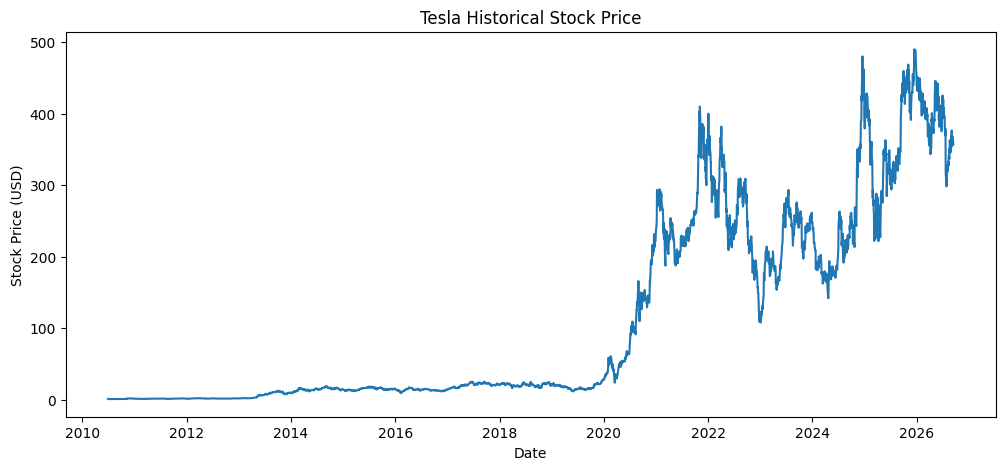

In [9]:
# Plotting Tesla Historical Stock Price using Matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tesla_data['Date'],tesla_data['Close'])
plt.title("Tesla Historical Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.show()



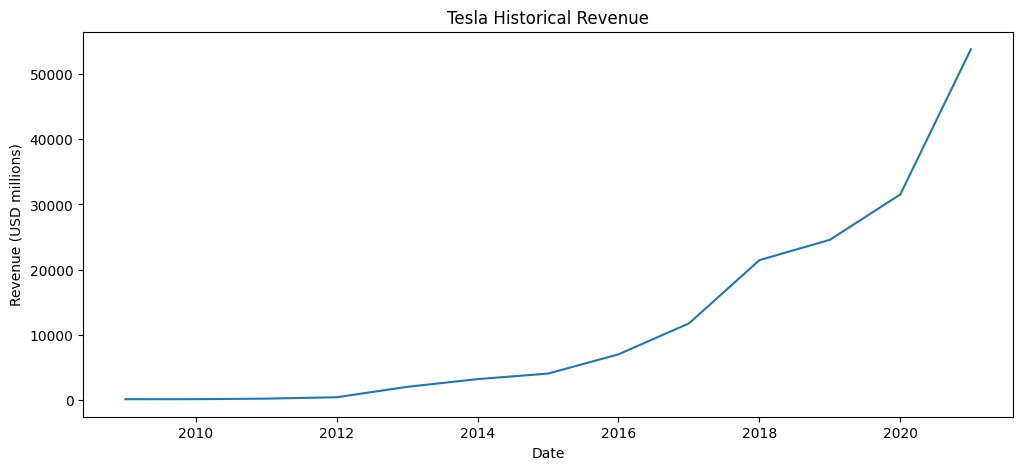

In [10]:
# Plotting Tesla Historical Revenue using Matplotlib

plt.figure(figsize=(12,5))
plt.plot(tesla_revenue['Date'],tesla_revenue['Revenue'])
plt.title("Tesla Historical Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (USD millions)")

plt.show()

In [11]:
# Analyzing maximum  revenue of Tesla:
tesla_revenue.loc[tesla_revenue["Revenue"].idxmax()]


,0
Date,2021-01-01 00:00:00
Revenue,53823


In [12]:
# Analyzing minimum revenue of Tesla:
tesla_revenue.loc[tesla_revenue["Revenue"].idxmin()]

,12
Date,2009-01-01 00:00:00
Revenue,112


# **Gamestop Stock Data and Revenue**

In [13]:
# Using yfinance to Extract Stock Data for Gamestop
gamestop=yf.Ticker("GME")
gamestop_data=gamestop.history(period="max")
gamestop_data.reset_index(inplace=True)
gamestop_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [15]:
# Using Webscraping to Extract Gamestop Revenue

link= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
page2=requests.get(link)
soup2=BeautifulSoup(page2.text,"html.parser")
gamestop_revenue=pd.DataFrame(columns=["Date","Revenue"])
rows2=soup2.find("tbody").find_all("tr")
for i in rows2:
  col=i.find_all("td")
  date=col[0].text
  revenue=col[1].text.replace(",","")[1:]
  gamestop_revenue.loc[len(gamestop_revenue)]=[date,revenue]
gamestop_revenue = gamestop_revenue.sort_values("Date")
gamestop_revenue.head()


,Date,Revenue
15,2005,1843
14,2006,3092
13,2007,5319
12,2008,7094
11,2009,8806


In [16]:
# Gamestop data inspection and cleaning
gamestop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6186 entries, 0 to 6185
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          6186 non-null   datetime64[ns, America/New_York]
 1   Open          6186 non-null   float64                         
 2   High          6186 non-null   float64                         
 3   Low           6186 non-null   float64                         
 4   Close         6186 non-null   float64                         
 5   Volume        6186 non-null   int64                           
 6   Dividends     6186 non-null   float64                         
 7   Stock Splits  6186 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 386.8 KB


In [17]:
# Gamestop revenue inspection
gamestop_revenue.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 15 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     16 non-null     object
 1   Revenue  16 non-null     object
dtypes: object(2)
memory usage: 940.0+ bytes


In [18]:
# Gamestop revenue preprocessing and cleaning
# Both date and revenue columns type are object which needs preprocessing

gamestop_revenue["Date"] = pd.to_datetime(gamestop_revenue["Date"],format="%Y")
gamestop_revenue['Revenue']=pd.to_numeric(gamestop_revenue['Revenue'])
gamestop_revenue.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 15 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     16 non-null     datetime64[ns]
 1   Revenue  16 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 940.0 bytes


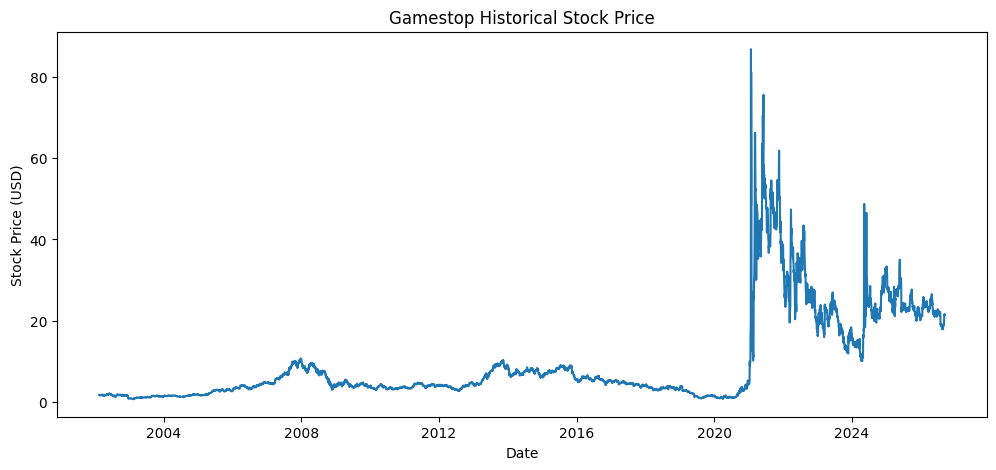

In [19]:
# Plotting Gamestop Historical Stock Price using Matplotlib

plt.figure(figsize=(12,5))
plt.plot(gamestop_data['Date'],gamestop_data['Close'])
plt.title("Gamestop Historical Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.show()


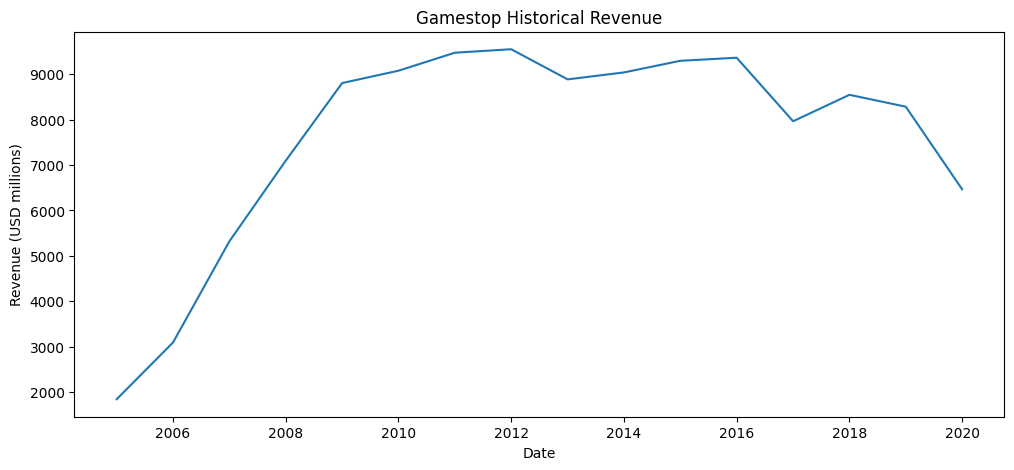

In [20]:
# Plotting Gamestop Historical Revenue using Matplotlib

plt.figure(figsize=(12,5))
plt.plot(gamestop_revenue['Date'],gamestop_revenue['Revenue'])
plt.title("Gamestop Historical Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (USD millions)")

plt.show()

In [21]:
# Analyzing maximum revenue of Gamestop:
gamestop_revenue.loc[gamestop_revenue["Revenue"].idxmax()]


,8
Date,2012-01-01 00:00:00
Revenue,9551


In [22]:
# Analyzing minimum revenue of Gamestop:
gamestop_revenue.loc[gamestop_revenue["Revenue"].idxmin()]

,15
Date,2005-01-01 00:00:00
Revenue,1843


In [23]:
gamestop_revenue.head()

,Date,Revenue
15,2005-01-01,1843
14,2006-01-01,3092
13,2007-01-01,5319
12,2008-01-01,7094
11,2009-01-01,8806


# **Comparison Between Tesla and Gamestop Revenue**

In [24]:
# Tesla Revenue Growth
tesla_revenue['Revenue_Growth_%']=tesla_revenue['Revenue'].pct_change()*100

tesla_revenue.head()

,Date,Revenue,Revenue_Growth_%
12,2009-01-01,112,NaN
11,2010-01-01,117,4.464286
10,2011-01-01,204,74.358974
9,2012-01-01,413,102.450980
8,2013-01-01,2013,387.409201


In [25]:
# Gamestop Revenue Growth
gamestop_revenue['Revenue_Growth_%']=gamestop_revenue['Revenue'].pct_change()*100
gamestop_revenue.head()

,Date,Revenue,Revenue_Growth_%
15,2005-01-01,1843,NaN
14,2006-01-01,3092,67.769940
13,2007-01-01,5319,72.024580
12,2008-01-01,7094,33.370934
11,2009-01-01,8806,24.133070


In [26]:
# Identifying Tesla and GameStop revenue overlapping years
common_years = sorted(set(tesla_revenue["Date"].dt.year) & set(gamestop_revenue["Date"].dt.year))
common_years

[2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

In [27]:
# Filtering both datasets to the overlapping years

tesla_growth = tesla_revenue[tesla_revenue["Date"].dt.year.isin(common_years)]

gamestop_growth = gamestop_revenue[gamestop_revenue["Date"].dt.year.isin(common_years)]

In [28]:
# Creating data frame including common years, Tesla Growth Percentage and Gamestop Growth Percentage

comparison=pd.DataFrame({'Year':tesla_growth['Date'].dt.year,
                         'Tesla Growth %':tesla_growth['Revenue_Growth_%'].values,
                         'Gamestop Growth':gamestop_growth['Revenue_Growth_%'].values})
comparison

,Year,Tesla Growth %,Gamestop Growth
12,2009,NaN,24.133070
11,2010,4.464286,3.088803
10,2011,74.358974,4.362194
9,2012,102.450980,0.812751
8,2013,387.409201,-6.952152
7,2014,58.867362,1.721616
6,2015,26.516573,2.831858
5,2016,73.010381,0.731497
4,2017,67.985714,-14.940196
3,2018,82.507016,7.306968


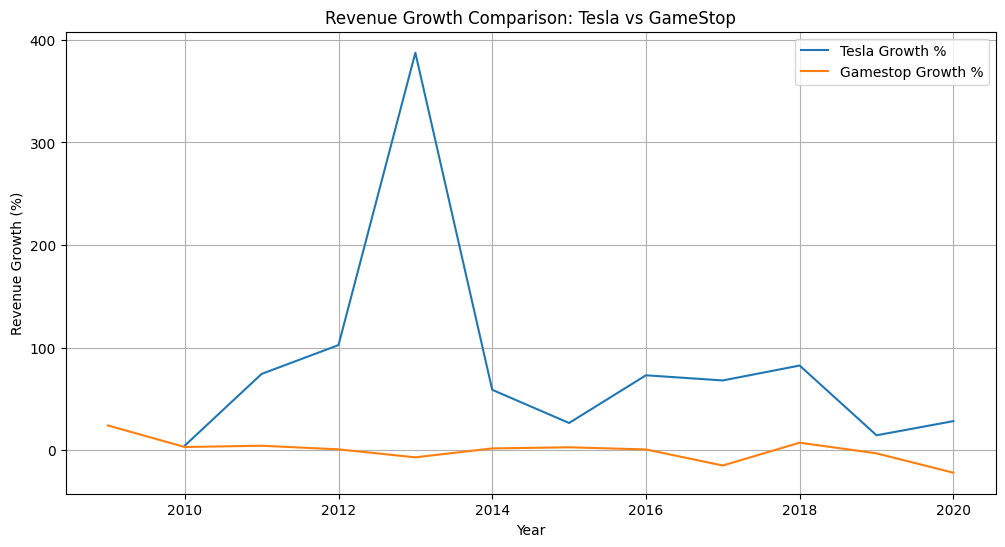

In [29]:
# Plotting Line Chart for Revenue Growth % for Tesla and Gamestop

plt.figure(figsize=(12,6))
plt.plot(comparison['Year'],comparison['Tesla Growth %'],label='Tesla Growth %')
plt.plot(comparison['Year'],comparison['Gamestop Growth'],label='Gamestop Growth %')
plt.title("Revenue Growth Comparison: Tesla vs GameStop")
plt.xlabel("Year")
plt.ylabel("Revenue Growth (%)")
plt.legend()
plt.grid(True)

plt.show()




***Insight:***

Tesla demonstrated stronger and more consistent revenue growth than GameStop during the overlapping period (2009–2020). Tesla's revenue growth remained positive throughout the period, with a notable spike in 2013, while GameStop experienced several years of negative growth.

# **Comparison Between Tesla and Gamestop Stock Performance**

In [30]:
# Identifying Tesla and GameStop stock data common dates:
common_dates = sorted(set(tesla_data["Date"]) & set(gamestop_data["Date"]))


In [31]:
# Filtering both stock datasets to their common trading dates

tesla_stock = tesla_data[tesla_data["Date"].isin(common_dates)]

gamestop_stock = gamestop_data[gamestop_data["Date"].isin(common_dates)]


In [32]:
# Creating data frame including common dates and close price for each

stock_comparison = pd.DataFrame({"Date": tesla_stock["Date"].values,
    "Tesla Close": tesla_stock["Close"].values,
    "GameStop Close": gamestop_stock["Close"].values})
stock_comparison.head()

,Date,Tesla Close,GameStop Close
0,2010-06-29 04:00:00,1.592667,3.083715
1,2010-06-30 04:00:00,1.588667,3.162827
2,2010-07-01 04:00:00,1.464000,3.209959
3,2010-07-02 04:00:00,1.280000,3.075299
4,2010-07-06 04:00:00,1.074000,3.097180


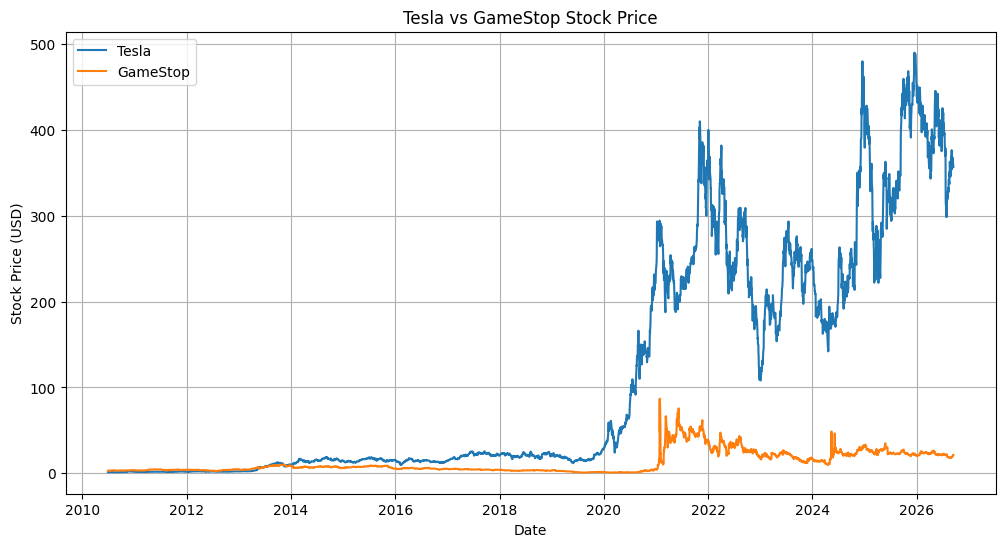

In [33]:
# Stock Price Comparison Graph

plt.figure(figsize=(12, 6))

plt.plot(stock_comparison["Date"], stock_comparison["Tesla Close"], label="Tesla")
plt.plot(stock_comparison["Date"], stock_comparison["GameStop Close"], label="GameStop")

plt.title("Tesla vs GameStop Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

***Insight:***

Tesla generally traded at a higher stock price than GameStop and showed greater price fluctuations. Tesla's stock price increased noticeably around 2020, while GameStop experienced a sharp increase around 2021.

# **Creating Interactive Dashboards Using Plotly**

In [44]:
# Creating Stock Price Comparison Interactive Graph
fig = px.line(stock_comparison,x="Date",y=["Tesla Close", "GameStop Close"],title="Tesla vs GameStop Stock Price",
    color_discrete_map={"Tesla Close": "blue","GameStop Close": "orange"})

fig.update_layout(xaxis_title="Date",yaxis_title="Stock Price (USD)")

fig.show()

In [47]:
# Creating Revenue Comparison Interactive Graph
import plotly.express as px
revenue_comparison = pd.DataFrame({
    "Year": tesla_growth["Date"].dt.year,
    "Tesla Revenue": tesla_growth["Revenue"].values,
    "GameStop Revenue": gamestop_growth["Revenue"].values})

fig = px.line(revenue_comparison, x="Year", y=["Tesla Revenue", "GameStop Revenue"],title="Tesla vs GameStop Revenue",color_discrete_map={"Tesla Revenue": "blue","GameStop Revenue": "orange"})

fig.update_layout(xaxis_title="Year", yaxis_title="Revenue (USD millions)")

fig.show()

In [46]:
# Creating Revenue Growth Comparison Interactive Graph


fig = px.line(comparison,x="Year",y=["Tesla Growth %", "Gamestop Growth"],title="Revenue Growth Comparison: Tesla vs GameStop",
color_discrete_map={"Tesla Growth %": "blue","Gamestop Growth": "orange"})

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Revenue Growth (%)"
)

fig.show()


# **Key Insights**

- Tesla demonstrated stronger and more consistent revenue growth than GameStop during the overlapping period (2009–2020).
- Tesla's revenue increased substantially over the analyzed period, while GameStop experienced several periods of negative revenue growth.
- Tesla generally traded at a higher stock price than GameStop and showed greater price fluctuations.
- GameStop experienced an increase in stock price around 2021, while Tesla's stock price also increased noticeably around 2020.

# **Conclusion**

This project analyzed and compared the historical stock performance and revenue trends of Tesla and GameStop.

The analysis showed clear differences in revenue growth and stock price movements between the two companies. Tesla experienced substantial revenue growth over the analyzed period, while GameStop's revenue growth was more variable. The stock price analysis also highlighted different patterns and periods of significant price movement.

Overall, the project demonstrates how financial data can be collected, cleaned, analyzed, and visualized using Python, Pandas, Matplotlib, and Plotly.

# **Creating Interactive Dashboard Using Streamlit**

In [49]:
# Creating CSV files for the latest data
stock_comparison.to_csv("stock_comparison.csv", index=False)
revenue_comparison.to_csv("revenue_comparison.csv", index=False)
comparison.to_csv("comparison.csv", index=False)

In [85]:
%%writefile requirements.txt

streamlit
pandas
plotly

Writing requirements.txt
